## Day 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import sys
import time


**Part 1**

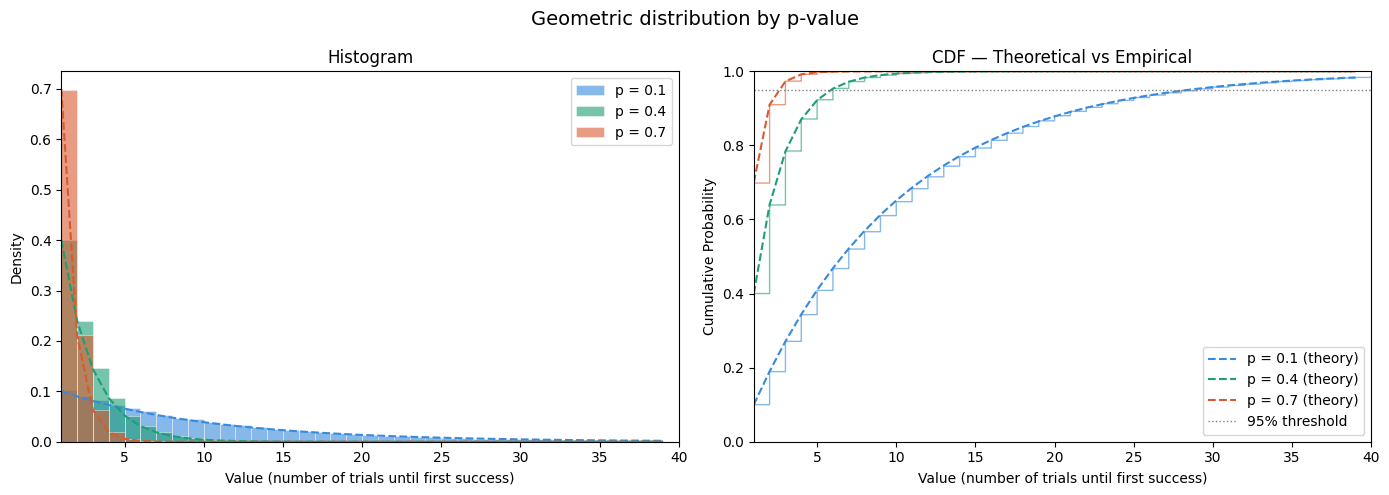

In [ ]:
P = [0.1, 0.4, 0.7]
N = 100000

# Generating observations of sample size N for the Geometric distribution 
func = {p: np.random.geometric(p, size=N) for p in P}

colors = {0.1: '#378ADD', 0.4: '#1D9E75', 0.7: '#D85A30'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Geometric distribution by p-value', fontsize=14)

### Histogram
ax = axes[0]
x = np.arange(1, 40)

for p, obs in func.items():
    ax.hist(obs, bins=range(1, 40), alpha=0.6, label=f'p = {p}',
            color=colors[p], edgecolor='white', linewidth=0.5, density=True)
    ax.plot(x, (1 - p)**(x - 1) * p, color=colors[p], linestyle='--', linewidth=1.5)

ax.set_xlabel('Value (number of trials until first success)')
ax.set_ylabel('Density')
ax.set_title('Histogram')
ax.legend()
ax.set_xlim(1, 40)

ax2 = axes[1]
x = np.arange(1, 40)

for p, obs in func.items():
    # Theoretical CDF: 1 - (1-p)^x
    ax2.plot(x, 1 - (1 - p)**x, color=colors[p], linestyle='--', linewidth=1.5, label=f'p = {p} (theory)')
    
    # Empirical CDF from simulation
    sorted_obs = np.sort(obs)
    ecdf = np.arange(1, len(sorted_obs) + 1) / len(sorted_obs)
    ax2.step(sorted_obs, ecdf, color=colors[p], alpha=0.6, linewidth=1)

ax2.set_xlabel('Value (number of trials until first success)')
ax2.set_ylabel('Cumulative Probability')
ax2.set_title('CDF — Theoretical vs Empirical')
ax2.set_xlim(1, 40)
ax2.set_ylim(0, 1)
ax2.axhline(0.95, color='gray', linestyle=':', linewidth=1, label='95% threshold')
ax2.legend()



plt.tight_layout()
plt.show()

**Part 2**

In [ ]:
P =[7/48, 5/48, 1/8, 1/16, 1/4, 5/16]

## Direct Method
def directMethod(P):
    cumprobs = np.cumsum(P)
    U = np.random.uniform()
    i = int(np.searchsorted(cumprobs, U))
    return i

## Rejection Method
def rejectionMethod(P):
    k = len(P)
    max_val = np.max(P)
    #c = max_val
    c = np.random.uniform(max_val,1)

    while True:
        U_1 = np.random.uniform()
        I = int(np.floor(k * U_1))
        U_2 = np.random.uniform()

        if U_2 <= P[I] / c:
            return I

# Generate G and L tables
def aliasSetup(P):
    eps = 1e-8
    k = len(P)
    L = list(range(k))
    F = list(np.array(P) * k)
    
    G = [i for i, f in enumerate(F) if f >= 1]
    S = [i for i, f in enumerate(F) if f < 1]

    while len(S) != 0:
        i, j = G[0], S[0]
        L[j] = i
        F[i] = F[i] - (1 - F[j])
        if F[i] < 1 - eps:
            G.pop(0)
            S.append(i)
        S.pop(0)
    
    return F, L

## Alias Method
def aliasMethod(P, F, L):
    k = len(P)
    U_1 = np.random.uniform()
    I = int(np.floor(k * U_1))
    U_2 = np.random.uniform()

    if U_2 <= F[I]:
        return I
    else:
        return L[I]
    
# Setup once, sample many times
F, L = aliasSetup(P)

methods = [directMethod, rejectionMethod, aliasMethod]


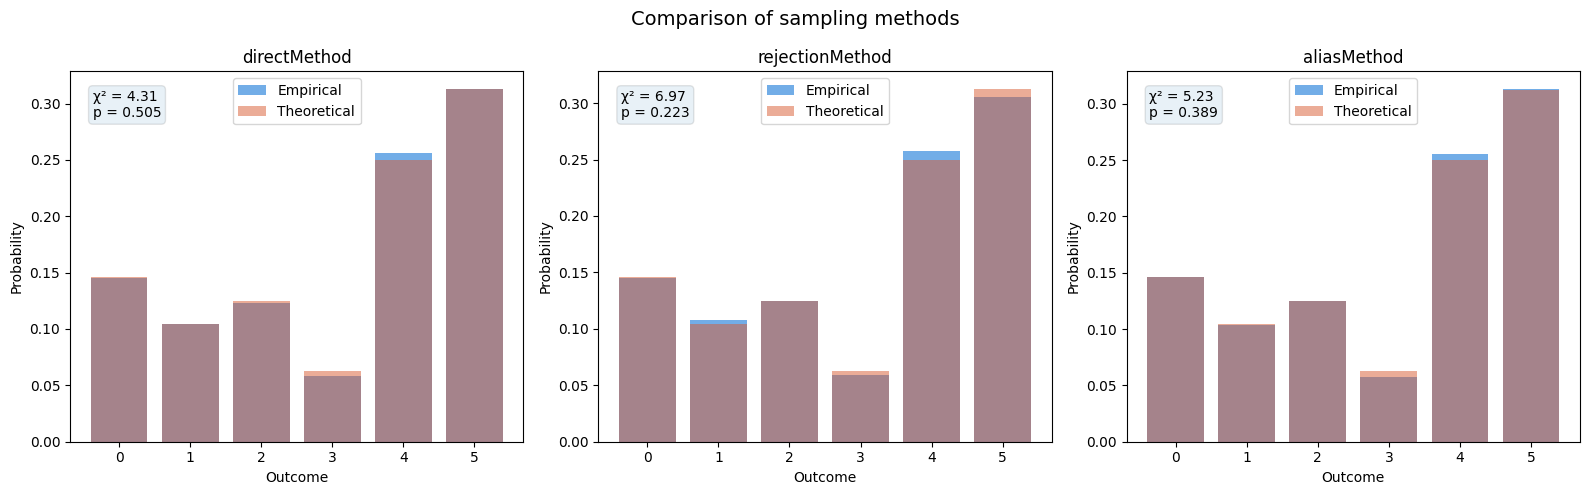

In [5]:
N = 10000
results = {
    'directMethod':    [directMethod(P) for _ in range(N)],
    'rejectionMethod': [rejectionMethod(P) for _ in range(N)],
    'aliasMethod':     [aliasMethod(P, F, L) for _ in range(N)]
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Comparison of sampling methods', fontsize=14)

x = np.arange(len(P))
expected = np.array(P) * N

for ax, (name, samples) in zip(axes, results.items()):
    observed = np.bincount(samples, minlength=len(P))
    
    # Histogram
    ax.bar(x, observed / N, alpha=0.7, label='Empirical', color='#378ADD')
    ax.bar(x, P, alpha=0.5, label='Theoretical', color='#D85A30')
    ax.set_title(name)
    ax.set_xlabel('Outcome')
    ax.set_ylabel('Probability')
    ax.legend()

    # Chi-squared test
    chi2, p_val = stats.chisquare(f_obs=observed, f_exp=expected)
    ax.text(0.05, 0.95, f'χ² = {chi2:.2f}\np = {p_val:.3f}',
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', alpha=0.1))

plt.tight_layout()

**Part 3**

In [ ]:
# Track total time for each method, samples of size 10000
def benchmark(sampler, name, n=10000):
    start = time.time()
    samples = [int(sampler()) for _ in range(n)]
    elapsed = time.time() - start
    print(f"{name}: {elapsed:.4f}s for {n} samples")
    return samples

F, L = aliasSetup(P)
samplers = {
    'directMethod':    lambda: directMethod(P),
    'rejectionMethod': lambda: rejectionMethod(P),
    'aliasMethod':     lambda: aliasMethod(P, F, L),
}

def accuracy(samples, P, k):
    counts = np.bincount(samples, minlength=k)
    empirical = counts / len(samples)

    # Total Variation Distance
    tvd = 0.5 * np.sum(np.abs(empirical - P))

    # Chi-square test
    expected = np.array(P) * len(samples)
    chi2, pval = stats.chisquare(counts, expected)

    print(f"Total Variation Distance: {tvd:.6f}  |  Chi2 p-value: {pval:.4f}")

In [ ]:
P = [7/48, 5/48, 1/8, 1/16, 1/4, 5/16]
n = 10000

# Run the test
for name, sampler in samplers.items():
    samples = benchmark(sampler, name, n=10000)
    accuracy(samples, P, len(P))

print("Memory:")
print(f"  Direct: cumprobs array: {sys.getsizeof(np.cumsum(P))} bytes")
print(f"  Rejection: no table, just P: {sys.getsizeof(P)} bytes")
print(f"  Alias: F + L tables: {sys.getsizeof(F) + sys.getsizeof(L)} bytes")

directMethod: 0.1526s for 10000 samples
Total Variation Distance: 0.008800  |  Chi2 p-value: 0.4046
rejectionMethod: 0.5380s for 10000 samples
Total Variation Distance: 0.006700  |  Chi2 p-value: 0.5063
aliasMethod: 0.1779s for 10000 samples
Total Variation Distance: 0.008700  |  Chi2 p-value: 0.4901
Memory:
  Direct: cumprobs array: 160 bytes
  Rejection: no table, just P: 104 bytes
  Alias: F + L tables: 208 bytes
